In [16]:
import pandas as pd

path = '/content/drive/MyDrive/ML_Project/heart.csv'

try:
    df = pd.read_csv(path)
    print("Success! Dataset loaded.")
    print(df.head())
except FileNotFoundError:
    print("Error: The file was not found at that path. Check your folder name!")

Success! Dataset loaded.
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [7]:

print("Missing Values per Column:")
print(df.isnull().sum())

# Get a statistical summary (mean, min, max) of the medical data
print("\nStatistical Summary:")
print(df.describe())

Missing Values per Column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Statistical Summary:
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997  131.623762  246.264026    0.148515   
std      9.082101    0.466011    1.032052   17.538143   51.830751    0.356198   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     47.500000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.000000    1.000000    1.000000  130.000000  240.000000    0.000000   
75%     61.000000    1.000000    2.000000  140.000000  274.500000    0.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000   

          re

In [8]:
from sklearn.model_selection import train_test_split

# Define Features (X) and Target (y)
X = df.drop('target', axis=1)
y = df['target']

# Split: 80% to train the model, 20% to test how "smart" it is
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data split! Training size: {len(X_train)}, Testing size: {len(X_test)}")

Data split! Training size: 242, Testing size: 61


In [11]:
from sklearn.preprocessing import StandardScaler

# Initialize the Scaler
scaler = StandardScaler()

# "Fit" the scaler on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data has been scaled successfully!")

Data has been scaled successfully!


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Initialize models (added max_iter to fix the Logistic Regression error)
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

# we are using X_train_scaled now
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    score = model.score(X_test_scaled, y_test)
    print(f"{name} Accuracy: {score:.2%}")

Logistic Regression Accuracy: 85.25%
Random Forest Accuracy: 81.97%
Support Vector Machine Accuracy: 86.89%
K-Nearest Neighbors Accuracy: 90.16%


In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# evaluated the Logistic Regression
best_model = models["Logistic Regression"]
y_pred = best_model.predict(X_test_scaled)

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



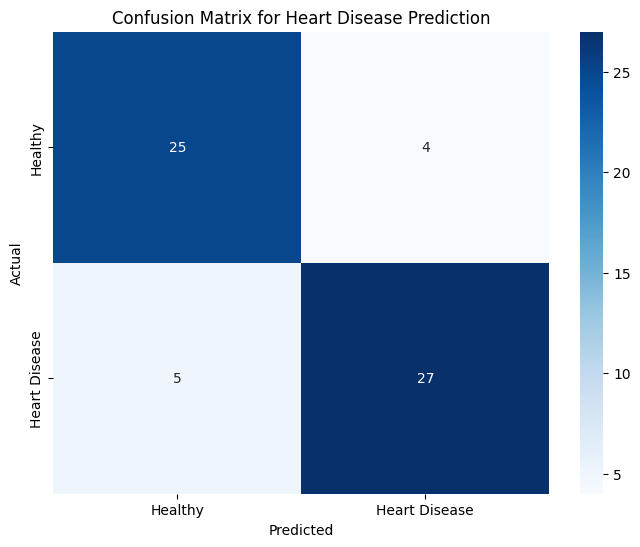

In [17]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Heart Disease'],
            yticklabels=['Healthy', 'Heart Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Heart Disease Prediction')
plt.show()

In [19]:
import joblib

# Saving
joblib.dump(best_model, 'heart_model.pkl')

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')

print("Model and Scaler saved as .pkl files!")

Model and Scaler saved as .pkl files!
